# ML & Preprocessing 

In [1]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)
from joblib import dump
import warnings 
warnings.filterwarnings('ignore')

# Make plots look nice 
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('✅ All libraries imported successfully!')



✅ All libraries imported successfully!


# Loaded Dataset

In [2]:
df = pd.read_csv('startup_founder_burnout_2026.csv')
print(f'📐 Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

📐 Dataset shape: 50,000 rows × 29 columns


,Founder_Type,Economic_Climate,Founder_Age,Founder_Experience_Years,Industry,Funding_Stage,Work_Mode,Team_Size,Startup_Age_Months,Weekly_Work_Hours,...,Founder_Burnout_Flag,Monthly_Revenue_Growth_Percent,Runway_Months_Remaining,Product_Market_Fit_Score,Employee_Turnover_Percent,Work_Life_Balance_Score,Seeks_Mental_Health_Support,Shutdown_Probability,Shutdown_Risk,Startup_Failure_Flag
0,Serial Entrepreneur,Recession,31,12,E-commerce,Seed,Remote,14,99,48.5,...,0,-5.1,5.6,7.8,30.0,9.7,No,0.082,Low,0
1,Calm Operator,Recession,30,0,FinTech,Bootstrapped,Remote,6,47,48.6,...,0,2.7,8.4,2.3,14.4,10.0,No,0.490,Medium,0
2,Burned-Out Operator,Stable Economy,28,3,ClimateTech,Bootstrapped,Hybrid,5,59,68.8,...,0,16.3,4.4,1.0,41.5,4.0,No,0.905,High,1
3,Chaotic Innovator,Stable Economy,32,2,EdTech,Series A,Office,74,143,81.5,...,0,-1.4,31.5,4.0,39.4,5.1,No,0.233,Low,0
4,Growth Obsessed Founder,Stable Economy,35,1,SaaS,Pre-Seed,Hybrid,9,11,78.6,...,0,21.6,7.0,5.2,36.5,4.2,No,0.716,High,1


# Exploratory Data Analysis (EDA)

Before building a model, we explore the data to understand the patterns

In [3]:
# Basic info about the dataset 
print("=== Dataset Info ===")
print(f"Total Founders: {len(df):,}")
print(f"Total Features: {df.shape[1]}")
print(f"Mising Values: {df.isnull().sum().sum()}")
print()

# Target Column Distribution 
print("=== Burnout Level Distribution ===")
print(df['Burnout_Level'].value_counts())

=== Dataset Info ===
Total Founders: 50,000
Total Features: 29
Mising Values: 0

=== Burnout Level Distribution ===
Burnout_Level
Low         27913
Moderate    16693
Severe       5394
Name: count, dtype: int64


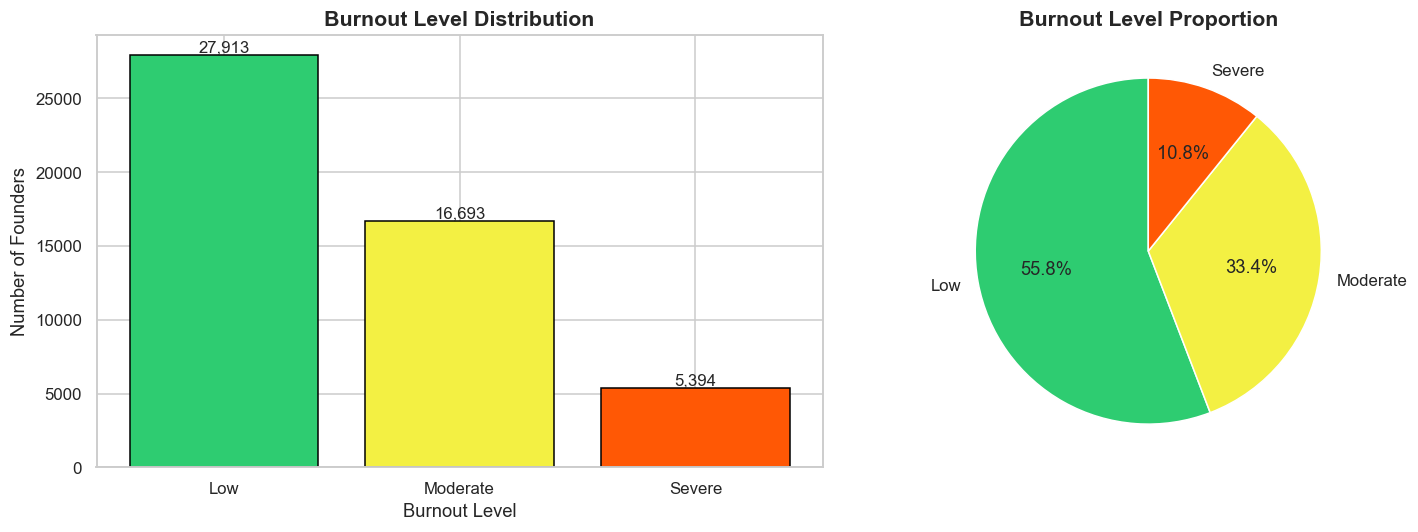

📊 Most founders (55.8%) are at LOW burnout — but 10.8% are SEVERELY burnt out!


In [4]:
# Plot 1: Burnout Level Counts 
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Bar Charts
burnout_counts = df['Burnout_Level'].value_counts()
colors = ['#2ecc71', "#f3f043", "#ff5805"]
axes[0].bar(burnout_counts.index, burnout_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Burnout Level Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Number of Founders')
for i, v in enumerate(burnout_counts.values):
    axes[0].text(i, v+200, f'{v:,}', ha='center', fontsize=11)

# Pie Charts
axes[1].pie(burnout_counts.values, labels=burnout_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Burnout Level Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('burnout_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Most founders (55.8%) are at LOW burnout — but 10.8% are SEVERELY burnt out!")

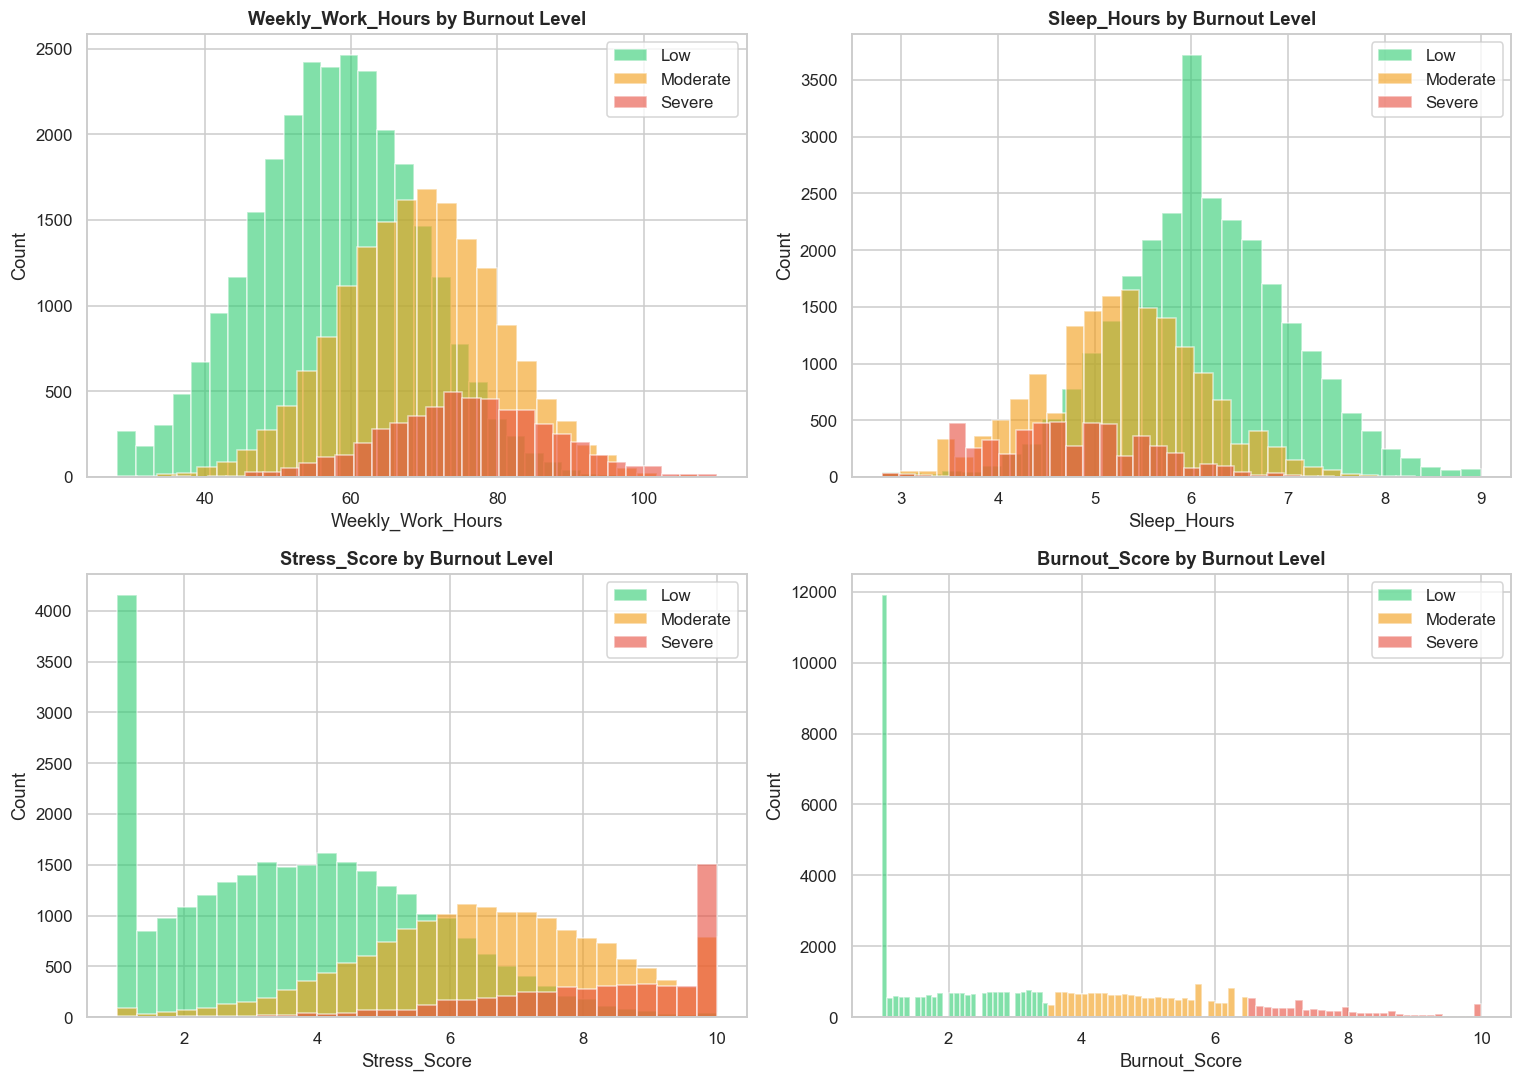

In [5]:
# Plot 2: Key numeric features vs Burnout Level
fig, axes = plt.subplots(2,2, figsize=(14, 10))

features_to_plot = ['Weekly_Work_Hours', 'Sleep_Hours', 'Stress_Score', 'Burnout_Score']
colors_palette = {'Low': '#2ecc71', 'Moderate': '#f39c12', 'Severe': '#e74c3c'}

for ax, feat in zip(axes.flatten(), features_to_plot):
    for level, color in colors_palette.items():
        data = df[df['Burnout_Level'] == level][feat]
        ax.hist(data, bins=30, alpha=0.6, label=level, color=color, edgecolor='white')
    ax.set_title(f"{feat} by Burnout Level", fontsize=12, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

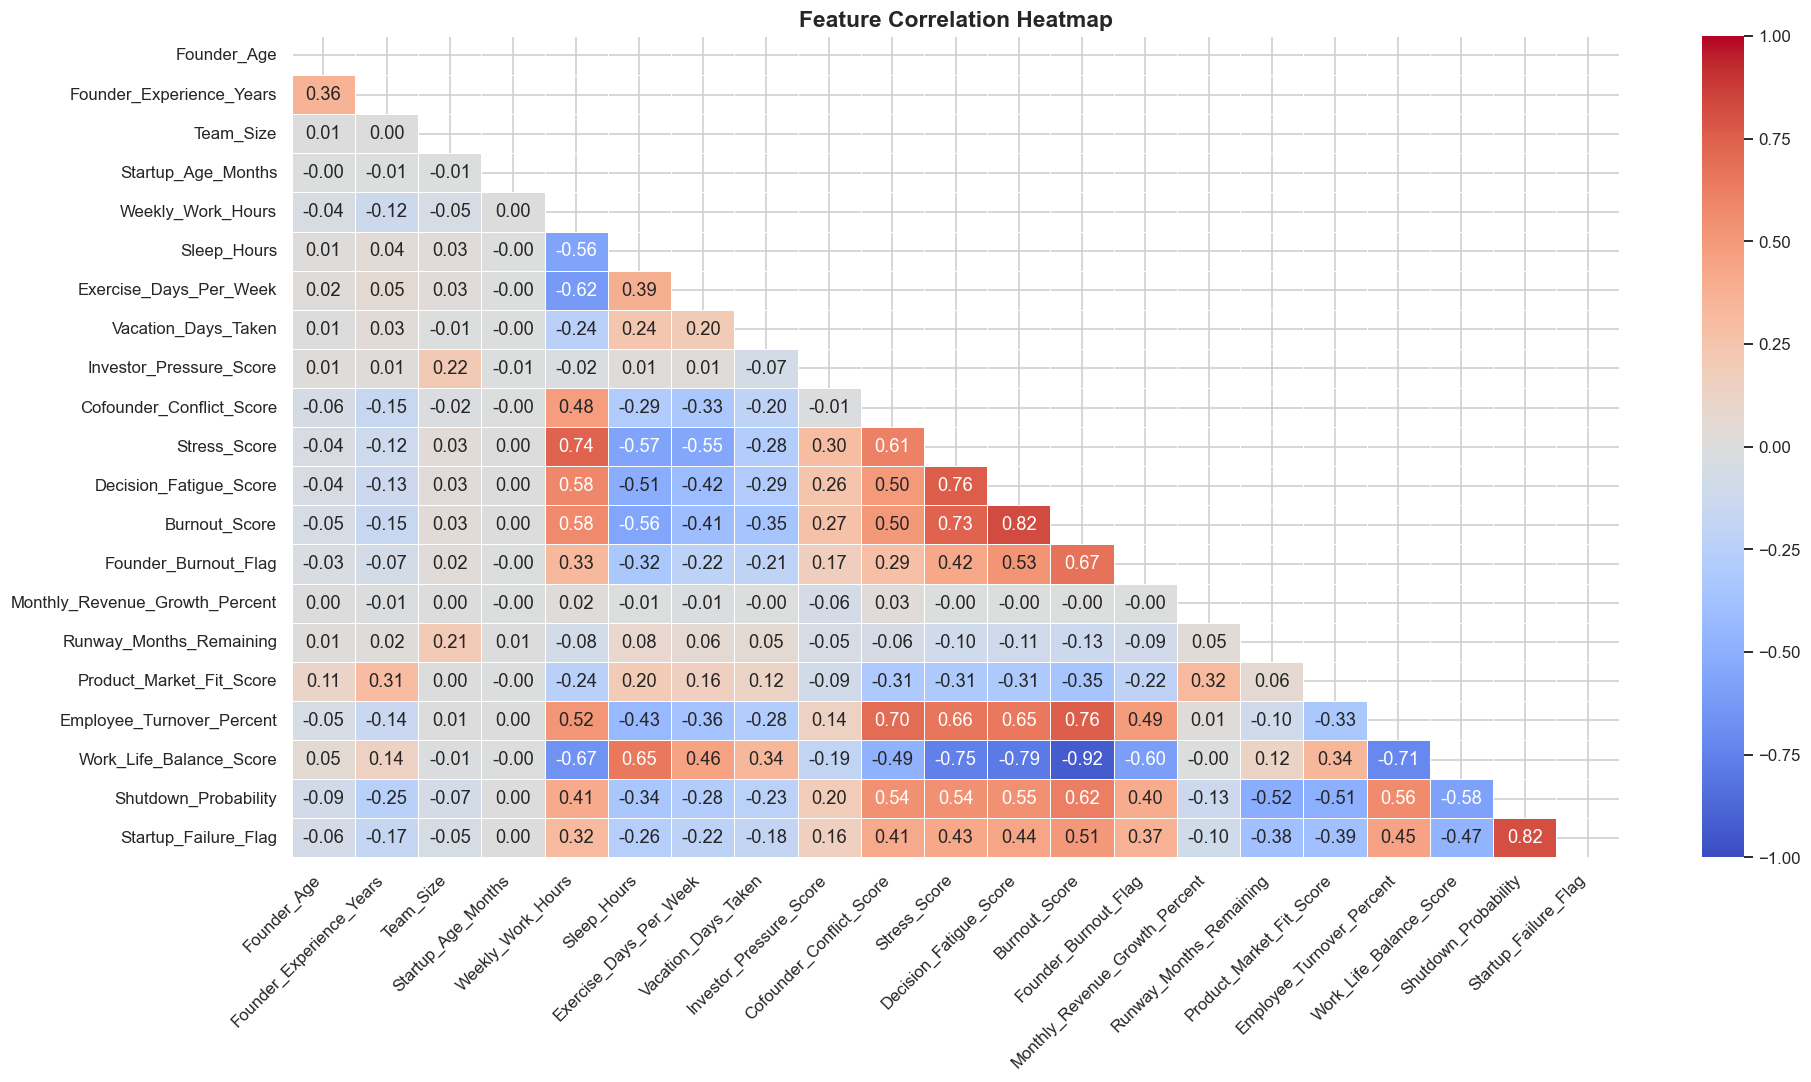

💡 High correlation between Burnout_Score and Stress_Score — makes sense!


In [6]:
# Plot 3: Correlation Heatmap 
plt.figure(figsize=(18,10))
num_cols = df.select_dtypes(include='number').columns
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 High correlation between Burnout_Score and Stress_Score — makes sense!")

In [7]:
# Separate features and target 
target_col = 'Burnout_Level'

# Drop out feature(s) 
drop_cols = [
    'Burnout_Level',        # target
    'Founder_Burnout_Flag', # leakage
    'Burnout_Score'         # leakage
]

# Encode target separately so we can decode later
le_target = LabelEncoder()
df[target_col] = le_target.fit_transform(df[target_col])

print(f"\nTarget classes: {list(le_target.classes_)}")
print("✅ Encoding done!")


Target classes: ['Low', 'Moderate', 'Severe']
✅ Encoding done!


# Splits into Train and Test

In [8]:
# Define X (features) and y (what we want to predict)
# We remove 'Founder_Burnout_Flag', 'Burnout_Score because they're derived from Burnout_Level (data leakage!)
X = df.drop(columns=[target_col] + drop_cols).copy()
y = df[target_col].copy()

# Separating dataset into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify text columns (except target)
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Missing Handling Values 

In [9]:
for c in num_cols:
    mean_val = X_train[c].mean()
    X_train[c] = X_train[c].fillna(mean_val)
    X_test[c] = X_test[c].fillna(mean_val)

for c in cat_cols:
    mode_series = X_train[c].mode(dropna=True)
    mode_val = mode_series.iloc[0] if len(mode_series) else "Available Missing Values"
    X_train[c] = X_train[c].fillna(mode_val)
    X_test[c] = X_test[c].fillna(mode_val)

# Encoding 

In [10]:
# Preprocesing: Encoding --> transferring into categorcial to numerical
onehot_cols = []
label_cols = []

for c in cat_cols:
    n_unique = X_train[c].nunique(dropna=True)
    # if n_unique <=5:
    #     onehot_cols.append(c)
    # else:
    label_cols.append(c)
print("One-hot columns (<=5 classes): ", onehot_cols)
print("Label-encoded columns (>5 classes): ", label_cols)

X_train_enc = X_train[num_cols].copy()
X_test_enc = X_test[num_cols].copy()


One-hot columns (<=5 classes):  []
Label-encoded columns (>5 classes):  ['Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage', 'Work_Mode', 'Seeks_Mental_Health_Support', 'Shutdown_Risk']


In [11]:
# Label encode each column using Train categories

for c in label_cols:
    X_train_enc[c] = X_train[c].astype("category").cat.codes
    # Use the same categories from train; unseen in test -> -1
    cats = X_train[c].astype("category").cat.categories
    X_test_enc[c] = pd.Categorical(X_test[c], categories=cats).codes
    

In [12]:
# # One-hot encode (train/test separately)
# X_train_oh = pd.get_dummies(X_train, columns = onehot_cols)
# X_test_oh = pd.get_dummies(X_test, columns = onehot_cols)

# # Make columns match 
# X_train_oh, X_test_oh = X_train_oh.align(X_test_oh, join='left', axis=1, fill_value=0)

# print("\nFinal Encoded Shapes: ")
# print("X_train_enc: ", X_train_enc.shape)
# print("X_test_enc: ", X_test_enc.shape)


In [13]:
X_train_enc.info()

<class 'pandas.DataFrame'>
Index: 40000 entries, 39087 to 15795
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Founder_Age                     40000 non-null  int64  
 1   Founder_Experience_Years        40000 non-null  int64  
 2   Team_Size                       40000 non-null  int64  
 3   Startup_Age_Months              40000 non-null  int64  
 4   Weekly_Work_Hours               40000 non-null  float64
 5   Sleep_Hours                     40000 non-null  float64
 6   Exercise_Days_Per_Week          40000 non-null  float64
 7   Vacation_Days_Taken             40000 non-null  float64
 8   Investor_Pressure_Score         40000 non-null  float64
 9   Cofounder_Conflict_Score        40000 non-null  float64
 10  Stress_Score                    40000 non-null  float64
 11  Decision_Fatigue_Score          40000 non-null  float64
 12  Monthly_Revenue_Growth_Percent  40000 non-nu

# Skewness 

In [14]:
numerical_cols = X_train_enc.select_dtypes(include=['int64', 'float64', 'int8']).columns
skewness = X_train_enc[numerical_cols].skew()
skewed_features = skewness[abs(skewness) > 0.80].index.tolist()

print("Skewed columns: ", skewed_features)
X_train_transformed = X_train_enc.copy()
X_test_transformed = X_test_enc.copy()

for col in skewed_features:
    if (X_train_transformed[col] >= 0).all():
        X_train_transformed[col] = np.log1p(X_train_transformed[col])
        X_test_transformed[col] = np.log1p(X_test_transformed[col])

Skewed columns:  ['Founder_Experience_Years', 'Team_Size', 'Startup_Failure_Flag', 'Seeks_Mental_Health_Support']


# LogisticRegression of features selection 

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# Logistic Regresion with L1
selector_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter = 5000,
    random_state=42
)

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Copy 
X_train_scaled_df = X_train_transformed.copy()
X_test_scaled_df = X_test_transformed.copy()

# Scaler 
scaler = StandardScaler()

# Scale
X_train_scaled = scaler.fit_transform(
    X_train_scaled_df
)
X_test_scaled = scaler.transform(
    X_test_scaled_df
)

# Fit 
selector_model.fit(
    X_train_scaled,
    y_train
)
selector = SelectFromModel(
    selector_model,
    prefit=True
)
# Mask
selected_mask = selector.get_support()

# Selected features
selected_features = X_train_transformed.columns[
    selected_mask
].tolist()

print("Selected Features: ")
print(selected_features)

# Final datasets
X_train_selected = X_train_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]


Selected Features: 
['Founder_Age', 'Founder_Experience_Years', 'Team_Size', 'Startup_Age_Months', 'Weekly_Work_Hours', 'Sleep_Hours', 'Exercise_Days_Per_Week', 'Vacation_Days_Taken', 'Investor_Pressure_Score', 'Cofounder_Conflict_Score', 'Stress_Score', 'Decision_Fatigue_Score', 'Monthly_Revenue_Growth_Percent', 'Runway_Months_Remaining', 'Product_Market_Fit_Score', 'Employee_Turnover_Percent', 'Work_Life_Balance_Score', 'Shutdown_Probability', 'Startup_Failure_Flag', 'Founder_Type', 'Economic_Climate', 'Industry', 'Funding_Stage', 'Work_Mode', 'Seeks_Mental_Health_Support', 'Shutdown_Risk']


In [16]:
# Final Model from selecting features for Logistic Regression 
log_model = LogisticRegression(
    random_state=42
)

# Train
log_model.fit(
    X_train_selected,
    y_train
)

# Prediction of Logistic Regression 
y_log_pred = log_model.predict(X_test_selected)
# Predicted probabilities for each class
y_prob_log = log_model.predict_proba(X_test_selected)

# Evaluation Metrics

In [17]:
accuracy = accuracy_score(y_test, y_log_pred)
precision = precision_score(y_test, y_log_pred, average='weighted')
recall = recall_score(y_test, y_log_pred, average='weighted')
f1 = f1_score(y_test, y_log_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob_log, multi_class='ovr', average='weighted')

print("Logistic Regression Metrics (after Lasso feature selection):")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")
print(f"ROC AUC  : {roc_auc:.2f}")

Logistic Regression Metrics (after Lasso feature selection):
Accuracy : 0.88
Precision: 0.88
Recall   : 0.88
F1 Score : 0.88
ROC AUC  : 0.97


# Random Forest Feature Importances

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Copy 
X_train_tree = X_train_transformed.copy()
X_test_tree = X_test_transformed.copy()

# Random Forest 
rf = RandomForestClassifier(
    n_estimators = 100, 
    random_state=42
)

# Fit 
rf.fit(
    X_train_tree,
    y_train
)

# Feature Importances
importances = pd.Series(
    rf.feature_importances_,
    index = X_train_tree.columns
)

# Sort
importances_sorted = importances.sort_values(
    ascending = False
)

# Top Features
top_features_tree = importances_sorted.index.tolist()
print("Top features for Tree Models")
print(top_features_tree)

# Selected datasets
X_train_tree_selected = X_train_tree[
    top_features_tree
]

X_test_tree_selected = X_test_tree[
    top_features_tree
]

Top features for Tree Models
['Work_Life_Balance_Score', 'Decision_Fatigue_Score', 'Employee_Turnover_Percent', 'Stress_Score', 'Shutdown_Probability', 'Weekly_Work_Hours', 'Sleep_Hours', 'Investor_Pressure_Score', 'Vacation_Days_Taken', 'Cofounder_Conflict_Score', 'Exercise_Days_Per_Week', 'Monthly_Revenue_Growth_Percent', 'Runway_Months_Remaining', 'Startup_Age_Months', 'Product_Market_Fit_Score', 'Team_Size', 'Founder_Age', 'Startup_Failure_Flag', 'Founder_Type', 'Industry', 'Founder_Experience_Years', 'Shutdown_Risk', 'Funding_Stage', 'Economic_Climate', 'Work_Mode', 'Seeks_Mental_Health_Support']


# Random Forest Classifier

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Model 
rf_model = RandomForestClassifier(
    random_state=42
)

# Train 
rf_model.fit(
    X_train_tree_selected,
    y_train
)

# Predict
y_pred_tree = rf_model.predict(
    X_test_tree_selected
)

# Probabilities 
y_prob_tree = rf_model.predict_proba(
    X_test_tree_selected
)

# Evaluation Metrics of Random Forest Classifier

In [20]:
accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

precision = precision_score(
    y_test,
    y_pred_tree,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_tree,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_tree,
    average='weighted'
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_tree,
    multi_class='ovr',
    average='weighted'
)

print("Random Forest Metrics:")

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")
print(f"ROC AUC  : {roc_auc:.2f}")

Random Forest Metrics:
Accuracy : 0.87
Precision: 0.87
Recall   : 0.87
F1 Score : 0.87
ROC AUC  : 0.96


# XGBoost Classifier

In [21]:
from xgboost import XGBClassifier

# n_jobs=-1 bu yerda ishlaydi
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, n_jobs=-1)
xgb.fit(
    X_train_tree_selected,
    y_train
)

y_pred_gb = xgb.predict(X_test_tree_selected)
y_prob_gb = xgb.predict_proba(X_test_tree_selected)

# Evaluation Metrics of XGBoost Classifier

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

precision = precision_score(
    y_test,
    y_pred_gb,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred_gb,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred_gb,
    average='weighted'
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_gb,
    multi_class='ovr',
    average='weighted'
)

print("XGBoost Metrics:")

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")
print(f"ROC AUC  : {roc_auc:.2f}")

XGBoost Metrics:
Accuracy : 0.87
Precision: 0.88
Recall   : 0.87
F1 Score : 0.87
ROC AUC  : 0.97


# Tabulate 

In [23]:
from tabulate import tabulate

# Metrics data
data = [
    ["Logistic Regression", 0.88, 0.88, 0.88, 0.88, 0.97],
    ["Random Forest", 0.87, 0.87, 0.87, 0.87, 0.96],
    ["XGBoost", 0.87, 0.88, 0.87, 0.87, 0.97]
]

# Column headers
headers = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

# Print tabulated table
print(tabulate(data, headers=headers, tablefmt="grid", floatfmt=".2f"))

+---------------------+------------+-------------+----------+------------+-----------+
| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   ROC AUC |
+=====================+============+=============+==========+============+===========+
| Logistic Regression |       0.88 |        0.88 |     0.88 |       0.88 |      0.97 |
+---------------------+------------+-------------+----------+------------+-----------+
| Random Forest       |       0.87 |        0.87 |     0.87 |       0.87 |      0.96 |
+---------------------+------------+-------------+----------+------------+-----------+
| XGBoost             |       0.87 |        0.88 |     0.87 |       0.87 |      0.97 |
+---------------------+------------+-------------+----------+------------+-----------+


In [24]:
best_score = max(model[1] for model in data)
best_result = []

for model in data:
    if model[1] == best_score and model[0] in ['Logistic Regression', 'Random Forest', 'XGBoost']:
        best_result.append(model)
        
for model in best_result:
    print(f"Best model from our dataset is {model[0]} and best metrics are accuracy score: {model[1]*100:.0f}%  and roc-auc score: {model[5]*100:.0f}%")

Best model from our dataset is Logistic Regression and best metrics are accuracy score: 88%  and roc-auc score: 97%


# SHAP Analysis 

In [25]:
import shap
import pandas as pd
import plotly.express as px

# SHAP explainer
explainer_log = shap.LinearExplainer(
    log_model,
    X_train_selected
)

# Only get 500 samples
X_sample = X_test_selected[:500]

# SHAP values
shap_values_log = explainer_log.shap_values(
    X_sample
)

# Multiclass
shap_2d_values = shap_values_log[:, :, 1]

# DataFrame
shap_df_log = pd.DataFrame(
    shap_2d_values,
    columns=selected_features
)

# Mean absolute SHAP
shap_importance_log = (
    shap_df_log.abs()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

shap_importance_log.columns = [
    'Feature',
    'Mean |SHAP Value|'
]

# Plot
fig = px.bar(
    shap_importance_log,
    x='Mean |SHAP Value|',
    y='Feature',
    orientation='h',
    title='Logistic Regression – SHAP Importance'
)

fig.update_layout(
    yaxis={'categoryorder':'total ascending'}
)

fig.show()

Background dataset has 40000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=40000 when initializing the masker.


# SHAP Analysis on Random Forest

In [26]:
# 500 sample
X_sample_tree = X_test_tree_selected.iloc[:500]

# SHAP
explainer_tree = shap.TreeExplainer(rf)

shap_values_tree = explainer_tree.shap_values(
    X_sample_tree,
    check_additivity=False
)
# check_additivity = False ==> matematik tekshiruvni o'tkazib yubor va to'xtab qolmasdan kodni oxirigacha ishlat
shap_values_class1 = shap_values_tree[:, :, 1]
shap_df_tree = pd.DataFrame(
    shap_values_class1,
    columns=X_sample_tree.columns
)

shap_signed = (
    shap_df_tree
    .mean()
    .sort_values()
    .reset_index()
)

shap_signed.columns = ["Feature", "Mean SHAP Value"]

fig = px.bar(
    shap_signed,
    x="Mean SHAP Value",
    y="Feature",
    orientation="h",
    title="Decision Tree – SHAP Values with Direction (+ / −)",
    color="Mean SHAP Value",
    color_continuous_scale="RdBu",
)

fig.update_layout(
    xaxis_title="Mean SHAP Value (Impact on Prediction)",
    yaxis_title="Feature"
)

fig.show()

# LOCAL SHAP Analysis on Random Forest 

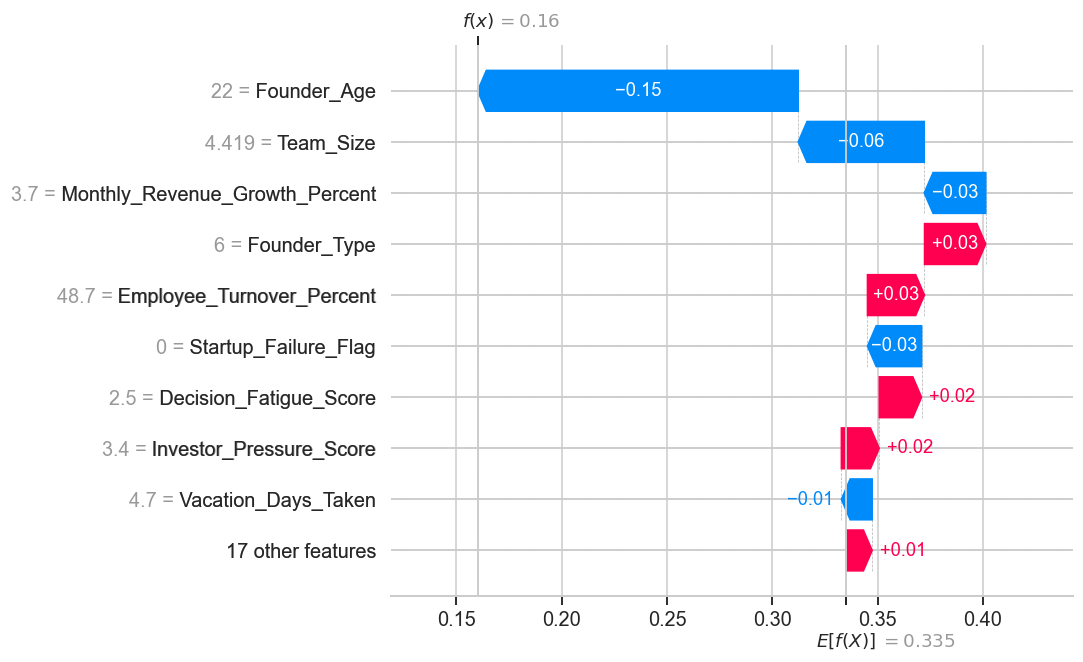

In [27]:
sample_idx = 0

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_tree[sample_idx, :, 1],
        base_values=explainer_tree.expected_value[1],
        data=X_sample_tree.iloc[sample_idx],
        feature_names=X_sample_tree.columns
    )
)

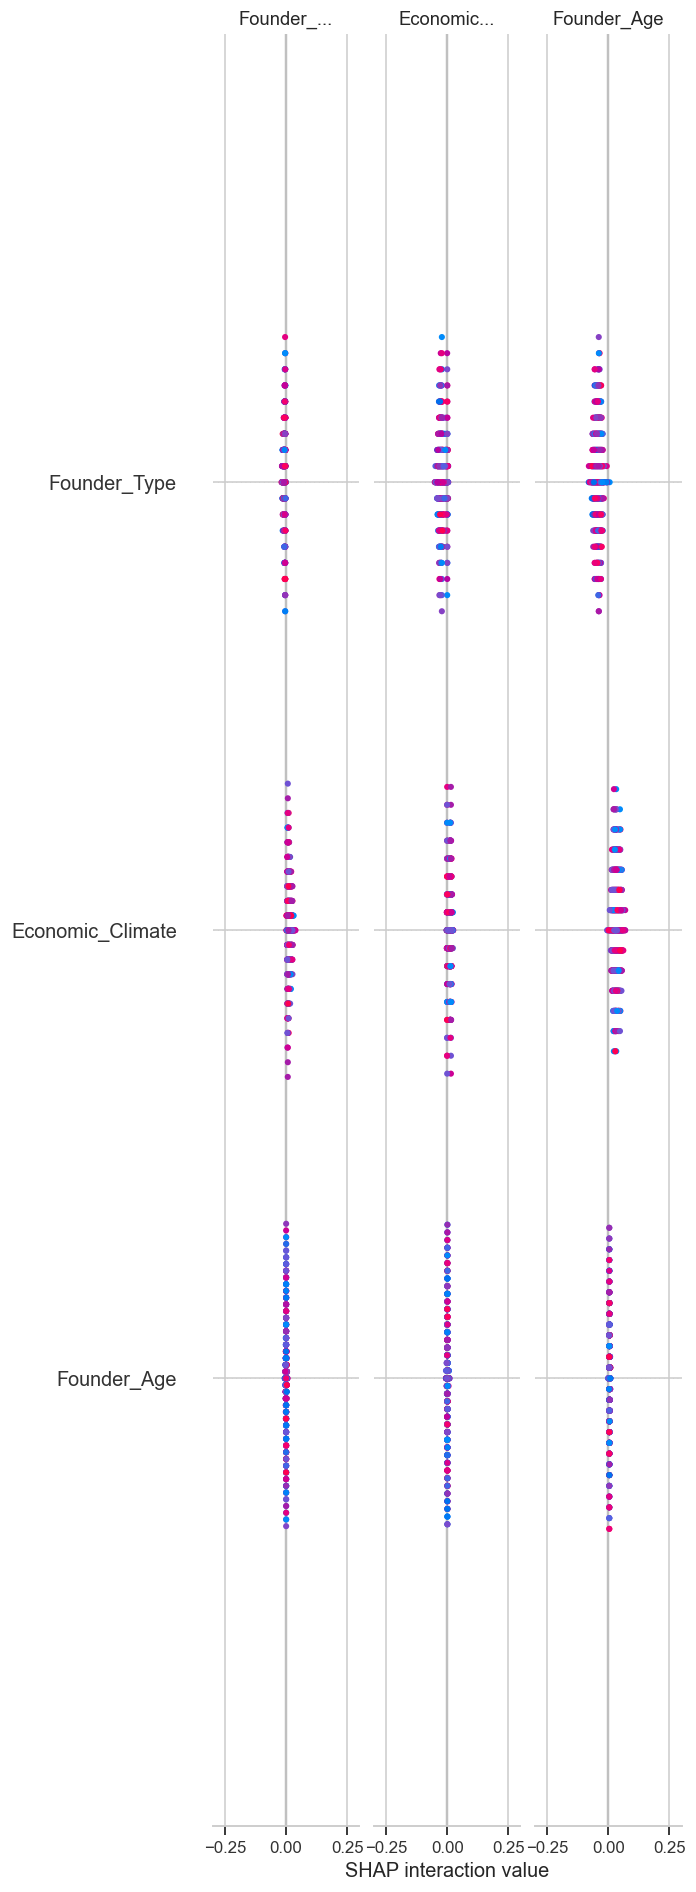

In [35]:
# Displaying with Summary Plot 
feature_names = X_train.columns.tolist()  # yoki X_test.columns.tolist()

X_sample_df = pd.DataFrame(X_sample, columns=feature_names)

shap.summary_plot(
    shap_values_tree,
    X_sample_df,
    max_display=20
)
plt.show()

# Save Best Model 

In [36]:
from joblib import dump
dump("y_log_pred", 'logreg_model.joblib')

['logreg_model.joblib']